<a href="https://colab.research.google.com/github/aakarshit15/synapseCoCommLP/blob/week2/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Synapse Week Two**

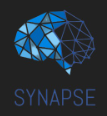

Last week, we dealt with the visualization and analytical aspect of ML. This week, lets directly get our hands dirty with various ML models.

Possibly the first question one must ask is, what is Machine Learning essentially made up of? In a broad sense, ML problems can be split into Supervised and Unsupervised learning. In supervised learning are the categories of Classification and Regression, which is what we'll explore today.

Like last time, resources and comments are provided above each cell, so peruse the resources and then get coding. Enough chitchat, lets get to work

Supervised vs Unsupervised vs Reinforcement Learning:

https://www.simplilearn.com/tutorials/machine-learning-tutorial/types-of-machine-learning

Regression vs Classification :

https://www.analyticsvidhya.com/blog/2023/05/regression-vs-classification/ (Might be a little wordy)

https://www.youtube.com/watch?v=1NBwM5tavTk&ab_channel=IntuitiveML
(A very quick video)

https://www.geeksforgeeks.org/ml-classification-vs-regression/
(Short and Sweet)

Machine Learning for Everyone (Read till 1.1):

https://vas3k.com/blog/machine_learning/

Overfitting and Underfitting [VERY IMPORTANT]
https://www.youtube.com/watch?v=T9NtOa-IITo

Lets import all the basic libraries.

In [1]:
# !pip install shap -q  #Will be used later on
!pip install shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 9.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Regression

For regression we will use the car sales dataset - https://drive.google.com/file/d/1dtwer8INIz05mULkV5yk8-Fzk2r3K1Of/view?usp=sharing

#### Basic EDA

Import dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Car_details.csv")

##### Do .head, .info and .describe in the subsequent cells

In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [ ]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


##### Plot a bar chart for the year, fuel and transmission columns

<Axes: xlabel='year', ylabel='count'>

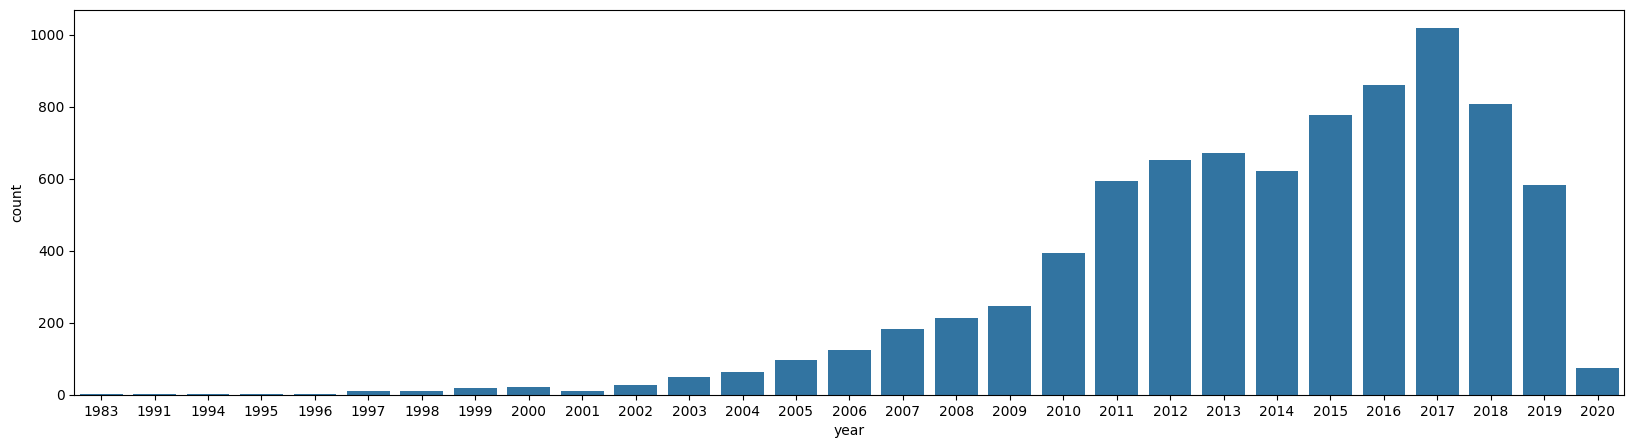

In [ ]:
fig, axes = plt.subplots(figsize=(20, 5))
sns.countplot(data=df, x="year", ax=axes)

<Axes: xlabel='fuel', ylabel='count'>

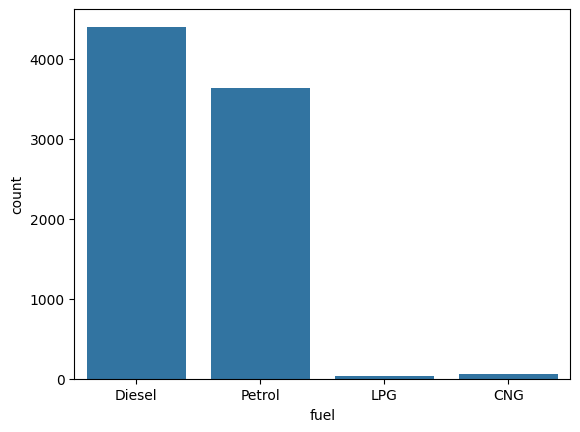

In [ ]:
sns.countplot(data=df, x="fuel")

<Axes: xlabel='transmission', ylabel='count'>

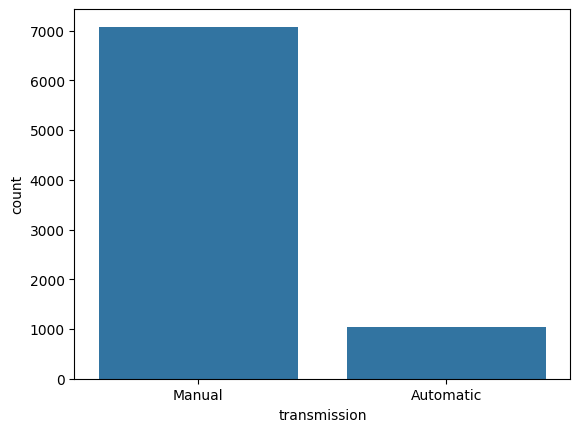

In [ ]:
sns.countplot(data=df, x="transmission")

##### Plot a pie chart for the owner and seats column

In [ ]:
owner_counts = df['owner'].value_counts()
owner_counts

,count
owner,
First Owner,5289
Second Owner,2105
Third Owner,555
Fourth & Above Owner,174
Test Drive Car,5


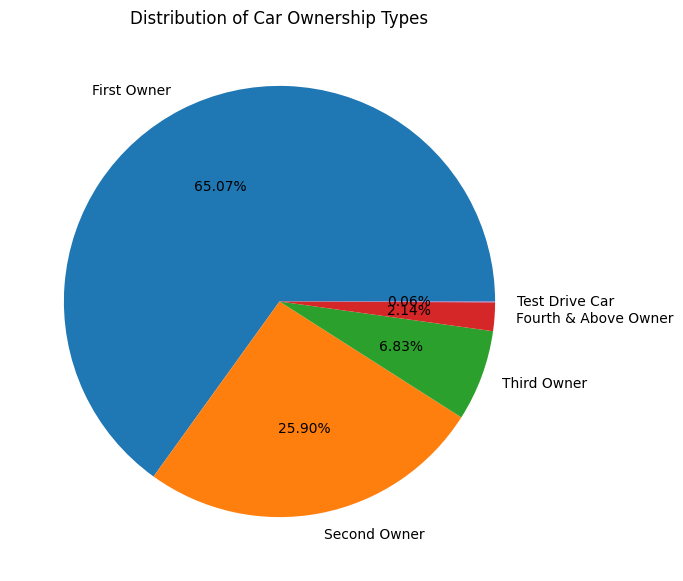

In [ ]:
owner_counts = df['owner'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(owner_counts, labels=owner_counts.index, autopct='%1.2f%%')
plt.title('Distribution of Car Ownership Types')
plt.show()

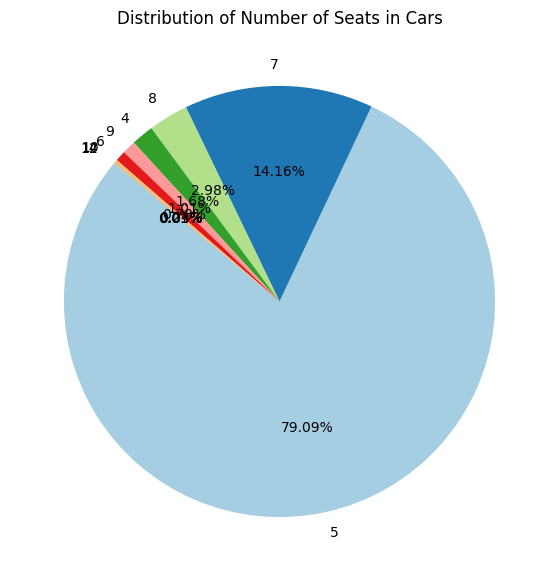

In [ ]:
seats_counts = df['seats'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(seats_counts, labels=seats_counts.index.astype(int), autopct='%1.2f%%', startangle=140, colors=sns.color_palette("Paired"))
plt.title('Distribution of Number of Seats in Cars')
plt.show()

##### Make a KDE plot to represent the engine column

##### Since the engine column is of type object you'll need to convert it to float and round it to the nearest 10 place as it would be easier to count and plot


In [ ]:
# code here
df['engine'] = df['engine'].str.replace('CC', '').astype(float)
df.head()
# code ends

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248.0,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498.0,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497.0,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396.0,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298.0,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   float64
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(2), int64(3), object(8)
memory usage: 825.6+ KB


Plot the graph

<Axes: xlabel='engine', ylabel='Density'>

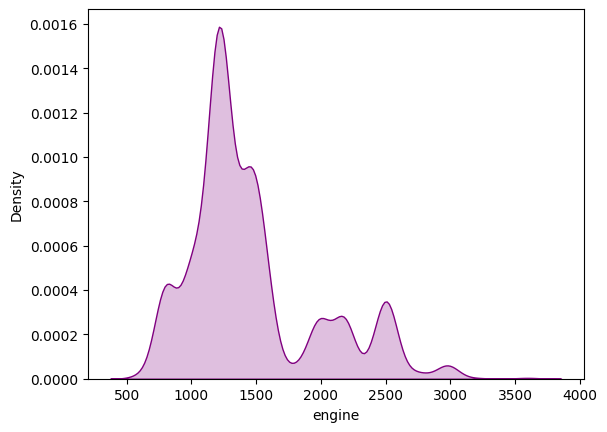

In [ ]:
sns.kdeplot(df.engine, fill=True, color="Purple")

##### Also make a countplot for the Engine column
hint: sns.countplot

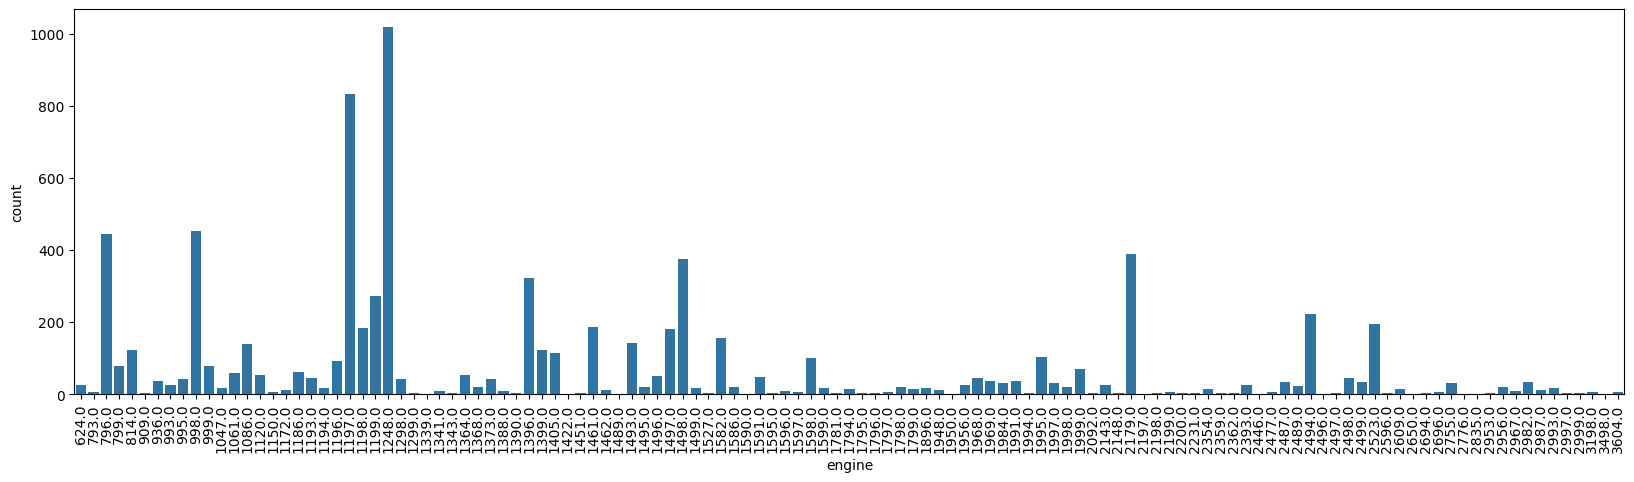

In [ ]:
#plot here
fig, axes = plt.subplots(figsize=(20, 5))
sns.countplot(data=df, x="engine", ax=axes)
axes.tick_params(axis='x', rotation=90)

##### As you can see in the Name column the entire name of the car is given, it will be very difficut to perfrom EDA and feed in this column into our Regression model so we will just extract the car manufacturer's name and create a new column Brand

In [ ]:
# code here
df['Brand'] = df['name'].str.split(' ').str[0]
df.head()
# code ends

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248.0,74 bhp,190Nm@ 2000rpm,5.0,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498.0,103.52 bhp,250Nm@ 1500-2500rpm,5.0,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497.0,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396.0,90 bhp,22.4 kgm at 1750-2750rpm,5.0,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298.0,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,Maruti


##### Plot a bar graph for the new column brand

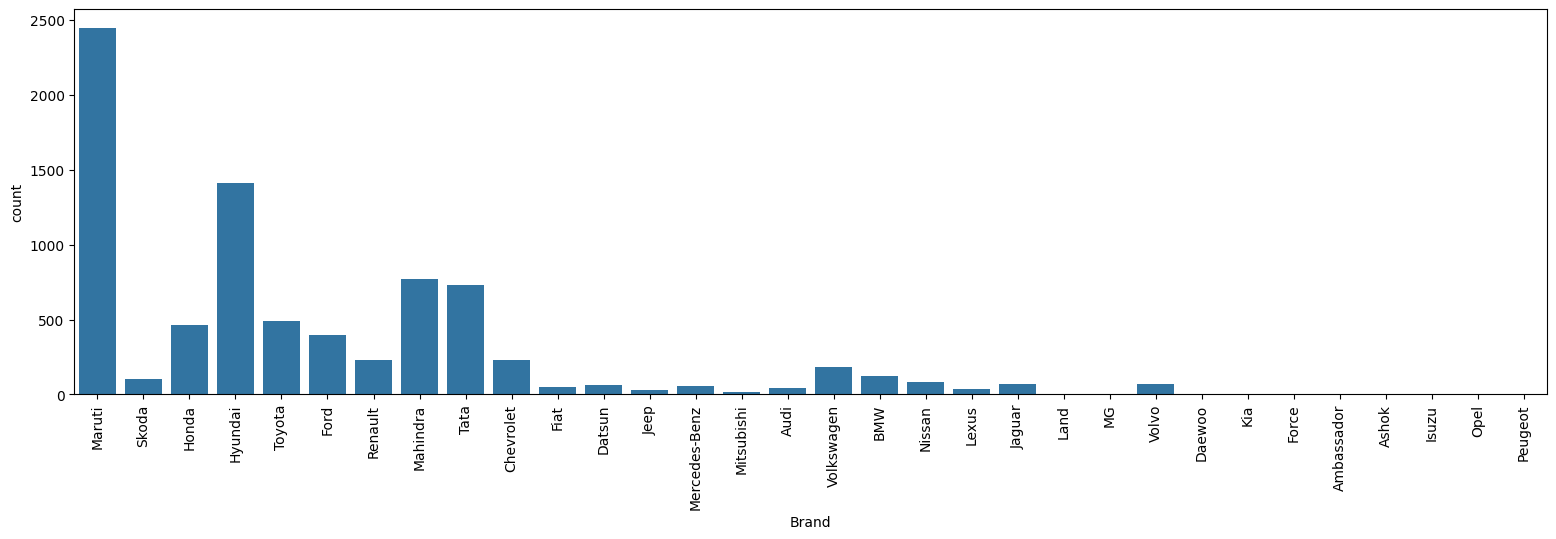

In [ ]:
#plot here
fig, axes = plt.subplots(figsize=(19, 5))
sns.countplot(data=df, x="Brand", ax=axes)
axes.tick_params(axis='x', rotation=90)

#### Perform a simiar process as Engine column for the Mileage column, extract the mileage number convert it to float and round it to the nearest 1's place

In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248.0,74 bhp,190Nm@ 2000rpm,5.0,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498.0,103.52 bhp,250Nm@ 1500-2500rpm,5.0,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497.0,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396.0,90 bhp,22.4 kgm at 1750-2750rpm,5.0,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298.0,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,Maruti


In [ ]:
# code here
df["mileage"] = df["mileage"].str.split(' ').str[0].astype("float")
df.head()
# code ends

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74 bhp,190Nm@ 2000rpm,5.0,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52 bhp,250Nm@ 1500-2500rpm,5.0,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90 bhp,22.4 kgm at 1750-2750rpm,5.0,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,Maruti


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   float64
 9   engine         7907 non-null   float64
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
 13  Brand          8128 non-null   object 
dtypes: float64(3), int64(3), object(8)
memory usage: 889.1+ KB


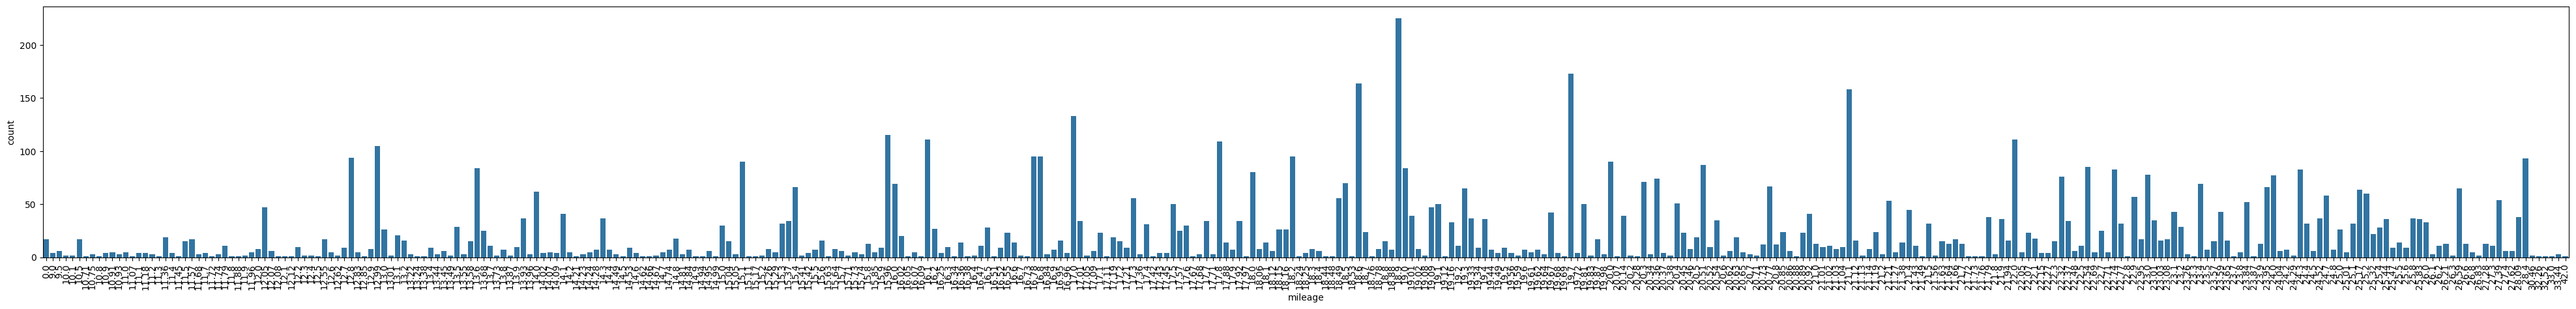

In [ ]:
# plot the count of each mileage value
fig, axes = plt.subplots(figsize=(50, 5))
sns.countplot(data=df, x="mileage", ax=axes)
axes.tick_params(axis='x', rotation=90)
# code here

If you want to do more analysis and make some graphs you are more than welcome :)

In [ ]:
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Brand,Age,fuel_label,seller_type_label,transmission_label,owner_label,Brand_label
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,Maruti,10,1,1,1,0,20
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,Skoda,10,1,1,1,2,27
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,Honda,18,3,1,1,4,10
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,Hyundai,14,1,1,1,0,11
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,Maruti,17,3,1,1,0,20


In [ ]:
df.describe()

,selling_price,km_driven,mileage,engine,max_power,seats,Age,fuel_label,seller_type_label,transmission_label,owner_label,Brand_label
count,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7912.000000,7907.000000,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000
mean,6.382718e+05,6.981951e+04,19.418783,1458.625016,91.517919,5.416719,10.195989,1.891117,0.890502,0.870817,0.814345,17.994833
std,8.062534e+05,5.655055e+04,4.037145,503.916303,35.822499,0.959588,4.044249,1.002313,0.394459,0.335423,1.221644,7.366546
min,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.549990e+05,3.500000e+04,16.780000,1197.000000,68.050000,5.000000,7.000000,1.000000,1.000000,1.000000,0.000000,11.000000
50%,4.500000e+05,6.000000e+04,19.300000,1248.000000,82.000000,5.000000,9.000000,1.000000,1.000000,1.000000,0.000000,20.000000
75%,6.750000e+05,9.800000e+04,22.320000,1582.000000,102.000000,5.000000,13.000000,3.000000,1.000000,1.000000,2.000000,20.000000
max,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000,41.000000,3.000000,2.000000,1.000000,4.000000,31.000000


In [ ]:
df["engine"].value_counts()

,count
engine,
1248.0,1017
1197.0,832
998.0,453
796.0,444
2179.0,389
...,...
2835.0,1
1489.0,1
1422.0,1


<Axes: xlabel='engine', ylabel='Density'>

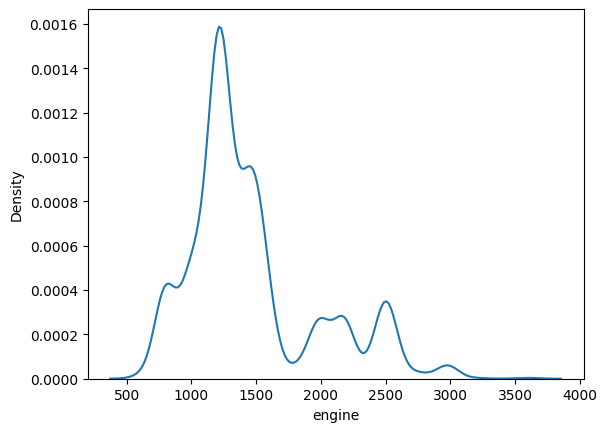

In [ ]:
sns.kdeplot(x="engine", data=df)

In [ ]:
df["max_power"].value_counts()

,count
max_power,
74.00,377
88.50,222
81.80,220
67.00,165
46.30,162
...,...
58.33,1
68.40,1
169.00,1


<Axes: xlabel='max_power', ylabel='Density'>

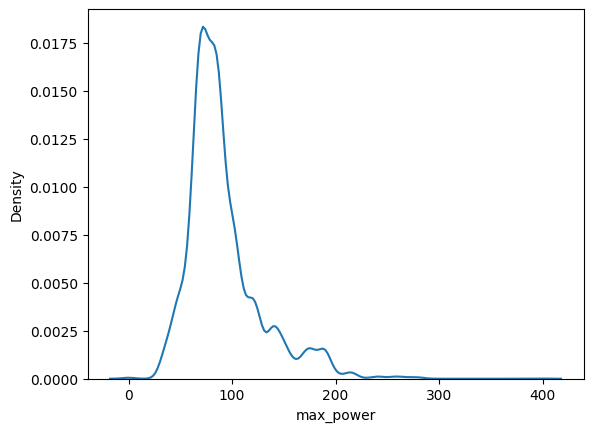

In [ ]:
sns.kdeplot(x="max_power", data=df)

<Axes: xlabel='seats'>

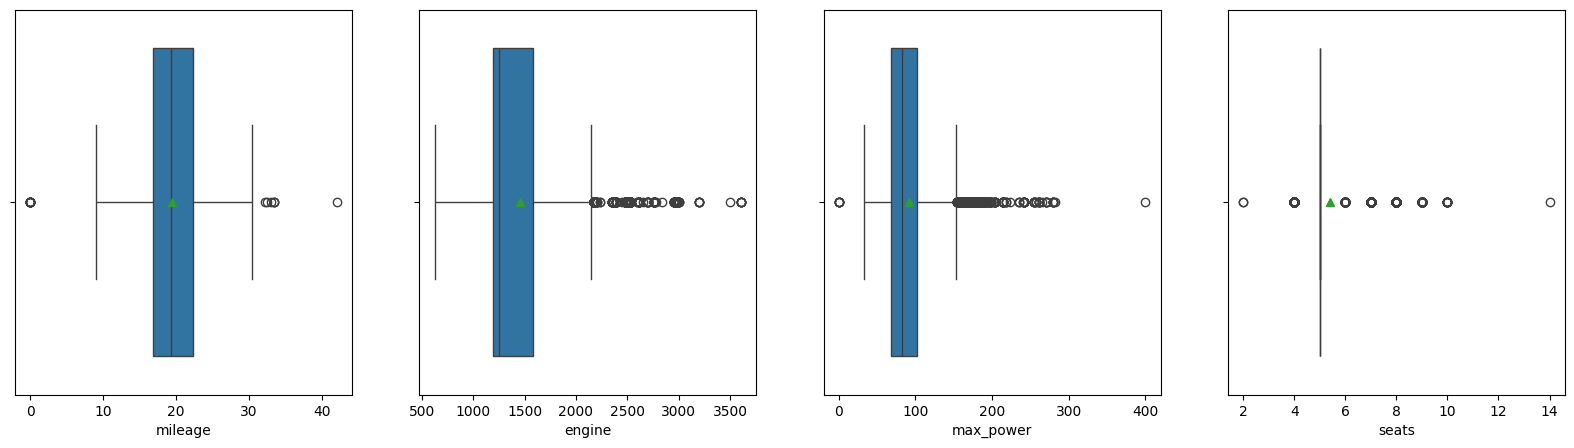

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.boxplot(x="mileage", data=df, ax=axes[0], showmeans=True)
sns.boxplot(x="engine", data=df, ax=axes[1], showmeans=True)
sns.boxplot(x="max_power", data=df, ax=axes[2], showmeans=True)
sns.boxplot(x="seats", data=df, ax=axes[3], showmeans=True)

## What do you infer from the above analysis

### Answer Here
1. Most of the cars uses Petrol and diesel car compare to LPG and CNG
2. Most of the cars are Manual compare to automatic
3. Most of the cars are first-owned 5 seaters
4. The mode of Engine CC lies around 1200
5. Most cars belong to Maruti
6. From box plots above I can infer that to replace NA values in mileage, engine, max_power I will use median and for seats I will use mode.


### Now let's prep our data to perform Regression to predict the Selling Price

##### As you can see the column max_power is of type object, we need to extract the max_power similar to Engine and Mileage columns

Be careful of NaN values in this part of the code, perform df.info() to look how many Nan value are present, you might face diffculties when you are trying to convert object to float in Nan values are present

In [ ]:
# code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   float64
 9   engine         7907 non-null   float64
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
 13  Brand          8128 non-null   object 
dtypes: float64(3), int64(3), object(8)
memory usage: 889.1+ KB


In [ ]:
# code ends
df['max_power'] = df['max_power'].str.split(' ').str[0]
df['max_power'] = pd.to_numeric(df['max_power'])
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,Maruti


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   float64
 9   engine         7907 non-null   float64
 10  max_power      7912 non-null   float64
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
 13  Brand          8128 non-null   object 
dtypes: float64(4), int64(3), object(7)
memory usage: 889.1+ KB


##### The year column contains the year the car was manufactured, but this data won't be directly useful to us
##### Use the current year to calculate the age of the car

In [ ]:
# code here
from datetime import datetime
current_year = int(datetime.now().strftime('%Y'))
df["Age"] = current_year - df["year"]
# drop the columns year and name
df = df.drop(['name', 'year'], axis=1)
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Brand,Age
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,Maruti,10
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,Skoda,10
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,Honda,18
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,Hyundai,14
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,Maruti,17


##### A few of the columns are still of dtype object, now we will be using Laber Encoder to encode these columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   selling_price  8128 non-null   int64  
 1   km_driven      8128 non-null   int64  
 2   fuel           8128 non-null   object 
 3   seller_type    8128 non-null   object 
 4   transmission   8128 non-null   object 
 5   owner          8128 non-null   object 
 6   mileage        7907 non-null   float64
 7   engine         7907 non-null   float64
 8   max_power      7912 non-null   float64
 9   torque         7906 non-null   object 
 10  seats          7907 non-null   float64
 11  Brand          8128 non-null   object 
 12  Age            8128 non-null   int64  
dtypes: float64(4), int64(3), object(6)
memory usage: 825.6+ KB


##### Import LaberEncoder from sklearn

In [ ]:
# import here
from sklearn.preprocessing import LabelEncoder
colums = ['fuel', 'seller_type', 'transmission', 'owner', 'Brand']
le = LabelEncoder()
for col in colums:
  df[col + '_label'] = le.fit_transform(df[col])
# code here
# code ends

Do df.head() to see how your dataframe looks like after LabelEncoding

In [ ]:
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Brand,Age,fuel_label,seller_type_label,transmission_label,owner_label,Brand_label
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,Maruti,10,1,1,1,0,20
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,Skoda,10,1,1,1,2,27
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,Honda,18,3,1,1,4,10
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,Hyundai,14,1,1,1,0,11
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,Maruti,17,3,1,1,0,20


##### The reason behind standardization and normalization will be explained in the later part of the task

##### For now we need to Normalize somem specific coloums
##### Import MinMaxScaler from sklearn and normalize the coloums - ['km_driven', 'mileage', 'engine', 'max_power', 'seats', 'age', 'selling_price']

In [ ]:
# import here
from sklearn.preprocessing import MinMaxScaler
# code here
df_norm = df.copy()
normScaler = MinMaxScaler()
norm_cols = ['km_driven', 'mileage', 'engine', 'max_power', 'seats', 'Age', 'selling_price']
for col in norm_cols:
  df_norm[col] = normScaler.fit_transform(df_norm[[col]])
df_norm = pd.DataFrame(df_norm)
df_norm.columns = df.columns
df_norm.head()
#code ends

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Brand,Age,fuel_label,seller_type_label,transmission_label,owner_label,Brand_label
0,0.042126,0.061640,Diesel,Individual,Manual,First Owner,0.557143,0.209396,0.1850,190Nm@ 2000rpm,0.25,Maruti,0.162162,1,1,1,0,20
1,0.034102,0.050837,Diesel,Individual,Manual,Second Owner,0.503333,0.293289,0.2588,250Nm@ 1500-2500rpm,0.25,Skoda,0.162162,1,1,1,2,27
2,0.012839,0.059310,Petrol,Individual,Manual,Third Owner,0.421429,0.292953,0.1950,"12.7@ 2,700(kgm@ rpm)",0.25,Honda,0.378378,3,1,1,4,10
3,0.019559,0.053803,Diesel,Individual,Manual,First Owner,0.547619,0.259060,0.2250,22.4 kgm at 1750-2750rpm,0.25,Hyundai,0.270270,1,1,1,0,11
4,0.010030,0.050837,Petrol,Individual,Manual,First Owner,0.383333,0.226174,0.2205,"11.5@ 4,500(kgm@ rpm)",0.25,Maruti,0.351351,3,1,1,0,20


In [ ]:
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Brand,Age,fuel_label,seller_type_label,transmission_label,owner_label,Brand_label
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,Maruti,10,1,1,1,0,20
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,Skoda,10,1,1,1,2,27
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,Honda,18,3,1,1,4,10
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,Hyundai,14,1,1,1,0,11
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,Maruti,17,3,1,1,0,20


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   selling_price       8128 non-null   int64  
 1   km_driven           8128 non-null   int64  
 2   fuel                8128 non-null   object 
 3   seller_type         8128 non-null   object 
 4   transmission        8128 non-null   object 
 5   owner               8128 non-null   object 
 6   mileage             7907 non-null   float64
 7   engine              7907 non-null   float64
 8   max_power           7912 non-null   float64
 9   torque              7906 non-null   object 
 10  seats               7907 non-null   float64
 11  Brand               8128 non-null   object 
 12  Age                 8128 non-null   int64  
 13  fuel_label          8128 non-null   int64  
 14  seller_type_label   8128 non-null   int64  
 15  transmission_label  8128 non-null   int64  
 16  owner_

In [ ]:
df_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   selling_price       8128 non-null   float64
 1   km_driven           8128 non-null   float64
 2   fuel                8128 non-null   object 
 3   seller_type         8128 non-null   object 
 4   transmission        8128 non-null   object 
 5   owner               8128 non-null   object 
 6   mileage             7907 non-null   float64
 7   engine              7907 non-null   float64
 8   max_power           7912 non-null   float64
 9   torque              7906 non-null   object 
 10  seats               7907 non-null   float64
 11  Brand               8128 non-null   object 
 12  Age                 8128 non-null   float64
 13  fuel_label          8128 non-null   int64  
 14  seller_type_label   8128 non-null   int64  
 15  transmission_label  8128 non-null   int64  
 16  owner_

In [ ]:
# Fill NaN values in the dataset
df_norm['mileage'] = df_norm['mileage'].fillna(df_norm['mileage'].median())
df_norm['engine'] = df_norm['engine'].fillna(df_norm['engine'].median())
df_norm['max_power'] = df_norm['max_power'].fillna(df_norm['max_power'].median())
df_norm['seats'] = df_norm['seats'].fillna(df_norm['seats'].mode()[0])
df_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   selling_price       8128 non-null   float64
 1   km_driven           8128 non-null   float64
 2   fuel                8128 non-null   object 
 3   seller_type         8128 non-null   object 
 4   transmission        8128 non-null   object 
 5   owner               8128 non-null   object 
 6   mileage             8128 non-null   float64
 7   engine              8128 non-null   float64
 8   max_power           8128 non-null   float64
 9   torque              7906 non-null   object 
 10  seats               8128 non-null   float64
 11  Brand               8128 non-null   object 
 12  Age                 8128 non-null   float64
 13  fuel_label          8128 non-null   int64  
 14  seller_type_label   8128 non-null   int64  
 15  transmission_label  8128 non-null   int64  
 16  owner_

In [ ]:
df_norm = df_norm.drop(["torque"], axis=1)
df_norm.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,Brand,Age,fuel_label,seller_type_label,transmission_label,owner_label,Brand_label
0,0.042126,0.061640,Diesel,Individual,Manual,First Owner,0.557143,0.209396,0.1850,0.25,Maruti,0.162162,1,1,1,0,20
1,0.034102,0.050837,Diesel,Individual,Manual,Second Owner,0.503333,0.293289,0.2588,0.25,Skoda,0.162162,1,1,1,2,27
2,0.012839,0.059310,Petrol,Individual,Manual,Third Owner,0.421429,0.292953,0.1950,0.25,Honda,0.378378,3,1,1,4,10
3,0.019559,0.053803,Diesel,Individual,Manual,First Owner,0.547619,0.259060,0.2250,0.25,Hyundai,0.270270,1,1,1,0,11
4,0.010030,0.050837,Petrol,Individual,Manual,First Owner,0.383333,0.226174,0.2205,0.25,Maruti,0.351351,3,1,1,0,20


As mentioned above, the 'selling_price' column is what we're gonna be predicting. So essentially we need to create two additional dataframes, one which contains all the training features (All columns except 'selling_price') and one which only contains the column 'selling_price'. Name them X and y respectively.

In [ ]:
# Seperate the Dataframe into X and y
y = df_norm["selling_price"]
y.head()

,selling_price
0,0.042126
1,0.034102
2,0.012839
3,0.019559
4,0.010030


In [ ]:
X = df_norm.drop(columns=["selling_price", "fuel", "Brand", "seller_type", "transmission", "owner"])
X.head()

,km_driven,mileage,engine,max_power,seats,Age,fuel_label,seller_type_label,transmission_label,owner_label,Brand_label
0,0.061640,0.557143,0.209396,0.1850,0.25,0.162162,1,1,1,0,20
1,0.050837,0.503333,0.293289,0.2588,0.25,0.162162,1,1,1,2,27
2,0.059310,0.421429,0.292953,0.1950,0.25,0.378378,3,1,1,4,10
3,0.053803,0.547619,0.259060,0.2250,0.25,0.270270,1,1,1,0,11
4,0.050837,0.383333,0.226174,0.2205,0.25,0.351351,3,1,1,0,20


### Train-Test Split

Implementation - https://www.youtube.com/watch?v=BUkqYGPnLZ8&ab_channel=ManifoldAILearning

Now, while we need data to train our regression model, it is equally important to keep some data aside for testing the effectiveness of the aforementioned model. Thus the dataset as a whole is generally further divided into the training dataset and the testing dataset.

In order to implement this, import train_test_split function from scikit-learn.

In [ ]:
# import here
from sklearn.model_selection import train_test_split

Print the size and shape of each of the train/test splits (it should be in the ratio as per test_size parameter above, i.e in ratio of 0.3)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5689, 11)
(2439, 11)
(5689,)
(2439,)


Can you see that the data has been divided into 2 datasets of size 70% and 30% of the original dataset each? Use your calculator to confirm this :)

### We have preprocessed our DataFrame now we'll perform Regression on this Data

### First lets understand Linear Regression, watch this video carefully it will be helpfull later on :)

https://www.youtube.com/watch?v=7ArmBVF2dCs

### A quick article
https://www.analyticsvidhya.com/blog/2021/08/understanding-linear-regression-with-mathematical-insights/

In [ ]:
# perfrom linear regression
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
# perform linear regression

# create an instance of LinearRegression
regressor = LinearRegression()

In [ ]:
# fit the model on the training data, hint: use the fit method
regressor.fit(X_train, y_train)

LinearRegression()

#### The X_train and y_train dataframes have been used to train the model. Now we will use X_test and y_test to evaluate the efficiency of the model we have trained.

#### Use regressor.predict() on X_test and store it in a variable called "y_pred". Print type and size of the y_pred.

#### Size should be (22009,) if everything is correct. Yeh line confirm karna hai

In [ ]:
# make predictions on the test data
y_pred = regressor.predict(X_test)
print(type(y_pred))
print(y_pred.shape)

<class 'numpy.ndarray'>
(2439,)


In [ ]:
# calculate the mean squared error
mse = mean_squared_error(y_test, y_pred)
mse

0.002402331334960263

In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2

0.693232121843167

### Visualize the predictions, plot a scatter plot of y_test vs y_pred and also plot the best fit line

<Axes: xlabel='selling_price'>

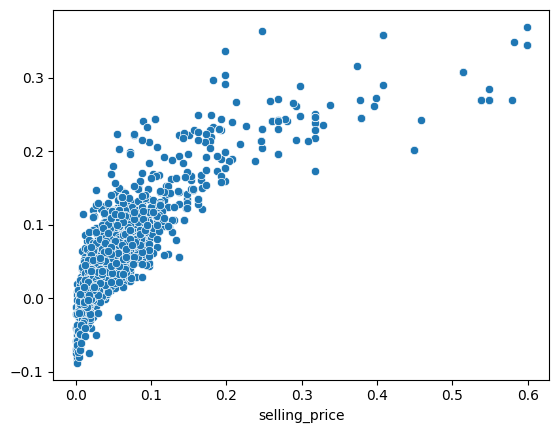

In [ ]:
#plot here
sns.scatterplot(x=y_test, y=y_pred)

# Now let's start the fun part :)

### Have you ever wondered what happens when you call **'regressor.fit(X_train, y_train)'** ?

### To understand what's hapenning in .fit method we will be implementing Linear Regression from scratch.

In [ ]:
class LinearRegression() :

    def __init__( self, learning_rate, iterations ) :
        # initialize the learning rate and iterations provides by the user
        self.learning_rate = learning_rate

        self.iterations = iterations

    # Function for model training
    def fit( self, X, Y ) :

        # no_of_training_examples, no_of_features
        self.m, self.n = X.shape[0], X.shape[1]

        # what does self.m and self.n represent and why are they calculated?
        # self.m is for the number of rows and self.n is for the number of independent varibales

        # weight initialization
        self.W = np.zeros(self.n)

        self.b = 0 # set this equal to 0

        self.X = X # set this equal to X

        self.Y = Y # set this equal to Y


        # gradient descent learning
        for i in range(self.iterations): # complete the range function

            self.update_weights()

        return self

    # Helper function to update weights in gradient descent
    def update_weights(self) :

        Y_pred = self.X.dot(self.W) + self.b# complete this line

        # calculate gradients
        dW = - ( 2 * ( self.X.T ).dot( self.Y - Y_pred )  ) / self.m
        db = - 2 * np.sum( self.Y - Y_pred ) / self.m

        # write the code to update the weights
        self.W = self.W - (self.learning_rate * dW)
        self.b = self.b - (self.learning_rate * db)

        return self


    def predict(self,X) :

        return X.dot(self.W) + self.b


In [ ]:
model = LinearRegression( iterations = 50000, learning_rate = 0.001 )

model.fit(X_train, y_train) # Explain in your own words what the fit function does

#### Answer Here
1. The fit function basically trains the model using the training independent ans training dependent variables
2. First we initailizes number of rows and independent variables in self.m and self.n
3. Then we initializes inital Weights and biases 0 and training independent and training dependent variables.
4. Then it update weights and biases based on each iterations, for this first it predicts y using formula y = X.W + b and then using the y we calculate new change in W i.e. dW and change in b i.e. db
5. Then we calculate new W and new b using learning rate.

In [ ]:
y_pred_model = model.predict(X_test)# code here

In [ ]:
y_pred_model.isna().sum()

0

In [ ]:
model_mse = mean_squared_error(y_test, y_pred_model)# Calculate the mean squared error
model_mse

0.0028100152220448967

In [ ]:
r2_model = r2_score(y_test, y_pred_model)
r2_model

0.641172558210263

<Axes: xlabel='selling_price', ylabel='None'>

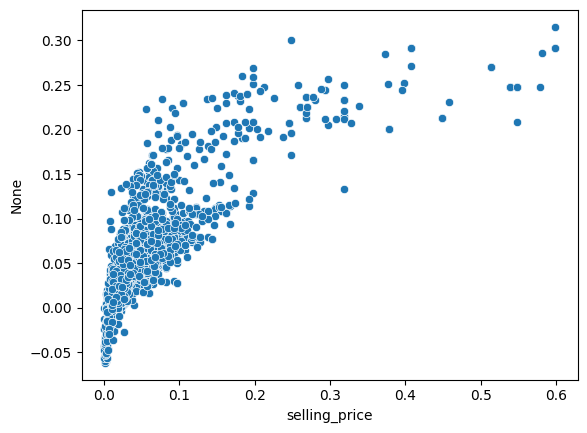

In [ ]:
# plot a similar scatter plot as above
sns.scatterplot(x=y_test, y=y_pred_model)

## Classification

#### In the below cells, we are going to implement K Nearest Neighbour Classification.

Link to the dataset is here - https://drive.google.com/file/d/1bVOfBJYUr0JtZ7pp1lcyNamnHHXn_fDm/view?usp=sharing <br>

Import the 'classified_data.txt' dataset using pandas and print the first five columns.

Use "index_col" parameter to index the dataframe according to the first column. Otherwise, a new column would get created. Call this new dataframe 'df'.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/classified_data.txt',index_col=0)
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


In [ ]:
df["TARGET CLASS"].value_counts()

,count
TARGET CLASS,
1,500
0,500


If you're wondering what these column names signify, well they are classified as the dataset name suggests. Our job here is to simply take the data at face value and build a model for classifying the target classes.

#### Basic EDA

##### In the following two cells, use info() and describe() to get the data type and statistical summary of the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   WTT           1000 non-null   float64
 1   PTI           1000 non-null   float64
 2   EQW           1000 non-null   float64
 3   SBI           1000 non-null   float64
 4   LQE           1000 non-null   float64
 5   QWG           1000 non-null   float64
 6   FDJ           1000 non-null   float64
 7   PJF           1000 non-null   float64
 8   HQE           1000 non-null   float64
 9   NXJ           1000 non-null   float64
 10  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 93.8 KB


In [ ]:
df.describe()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,0.949682,1.114303,0.834127,0.682099,1.032336,0.943534,0.963422,1.071960,1.158251,1.362725,0.50000
std,0.289635,0.257085,0.291554,0.229645,0.243413,0.256121,0.255118,0.288982,0.293738,0.204225,0.50025
min,0.174412,0.441398,0.170924,0.045027,0.315307,0.262389,0.295228,0.299476,0.365157,0.639693,0.00000
25%,0.742358,0.942071,0.615451,0.515010,0.870855,0.761064,0.784407,0.866306,0.934340,1.222623,0.00000
50%,0.940475,1.118486,0.813264,0.676835,1.035824,0.941502,0.945333,1.065500,1.165556,1.375368,0.50000
75%,1.163295,1.307904,1.028340,0.834317,1.198270,1.123060,1.134852,1.283156,1.383173,1.504832,1.00000
max,1.721779,1.833757,1.722725,1.634884,1.650050,1.666902,1.713342,1.785420,1.885690,1.893950,1.00000


**Run a 'for' loop to draw boxplots of all the features for '0' and '1' TARGET CLASS**<br>
##### Hint: Loop through each of the 10 features and draw a separate boxplot. You should have 10 boxplots in total. <br>
##### Refer seaborn boxplot() documentation

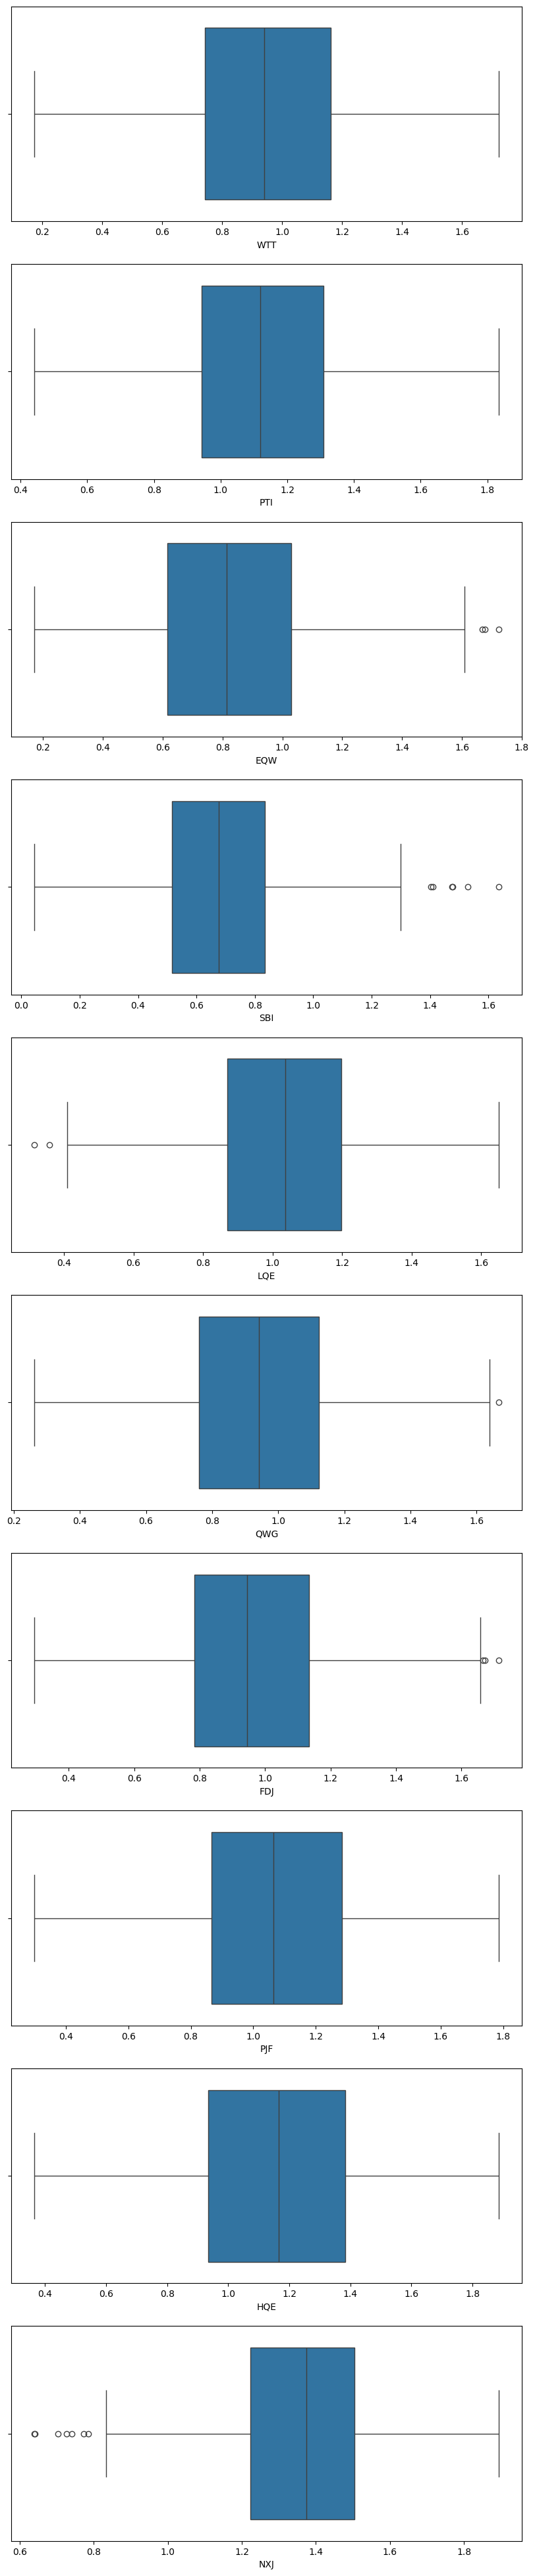

In [ ]:
#plot
fig, axes = plt.subplots(10, 1, figsize=(10, 50))
i=0
for col in df.columns:
  if(col=="TARGET CLASS"):
    break
  sns.boxplot(data=df, x=col, ax=axes[i])
  i = i+1

##### What conclusion, if any can you draw from these boxplots?
List them down below.

### Standardize the features using sklearn.preprocessing
Why should we standardize?<br>
Variables that are measured at different scales do not contribute equally to the model fitting & model learned function and might end up creating a bias. Thus, to deal with this potential problem feature-wise standardization is usually used prior to model fitting.<br><br>

To give you an example, values pertaining to Age usually lie within the range of 1-100, however values pertaining to Salary lie in a much wider range of say 10000-1000000. You can see how having both columns be a part of a classification model as is would lead to an imbalance in importance assigned to columns.
<br><br>
Go through this link for a better understanding:<br>
https://towardsdatascience.com/how-and-why-to-standardize-your-data-996926c2c832

##### **import StandardScaler from Sklearn and instantiate it to a variable called "scaler"**

In [ ]:
# your code starts here
from sklearn.preprocessing import StandardScaler
# your code ends here

##### **Fit only the features data to this scaler (leaving the TARGET CLASS column out) and then transform**<br>
##### Hint: scaler.fit() and scaler.transform()

In [ ]:
# your code starts here
df_feat = df.copy()
df_feat = df_feat.drop(["TARGET CLASS"], axis=1)
for col in df_feat.columns:
  stdScaler = StandardScaler().fit(df_feat[[col]])
  df_feat[col] = stdScaler.transform(df_feat[[col]])
df_feat.head()
# your code ends here

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


**scaler.transform() will return an array. We need to convert this into a dataframe. Do this and add the column names to the dataframe. Call this new dataframe as "df_feat". Call head() on this df**<br>
Note: The final dataframe will have the initial columns except the "TARGET CLASS".

In [ ]:
# your code starts here
df_feat.head()
# your code ends here

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


### Train/Test split

**Set X to be equal to df_feat and set y accordingly. As you know, X contains our training features and y contains our target.**<br>
Hint: y can be taken directly from the initial dataframe "df"

In [ ]:
X,y = df_feat.values[:,:], df.values[:,-1]

In [ ]:
X = pd.DataFrame(X)
X.head()

,0,1,2,3,4,5,6,7,8,9
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


In [ ]:
y = pd.DataFrame(y)
y.head()

,0
0,1.0
1,0.0
2,0.0
3,1.0
4,1.0


**Import train_test_split function from scikit-learn**<br>
**Create X and y train and test splits in one command using a test size of 0.3 and a random seed**<br>
They should be called X_train, X_test, y_train, y_test

In [ ]:
# Your code starts here.
from sklearn.model_selection import train_test_split
# Your code ends here

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(700, 10)
(300, 10)
(700, 1)
(300, 1)


### Model fit and training

Before moving ahead with the cells below, learn how the K Nearest Neighbour Algorithm actually works.

Theory and implementation : https://youtu.be/wTF6vzS9fy4 <br>
Theory: https://www.analyticsvidhya.com/blog/2018/08/k-nearest-neighbor-introduction-regression-python/

**import KNeighborsClassifier from sklearn and initialize it with neighbours = 1 (more on this later) . Fit this on X_train and y_train**

In [ ]:
# Your code starts here.
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
# Your code ends here

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:233: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=1)

**Using this fitted model, predict on X_test. Store these predictions in variable called pred.**

In [ ]:
# Your code starts here.
pred = knn.predict(X_test)
pred
# Your code ends here

array([0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 1., 1., 0., 0.,
       0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 1.,
       1., 0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1.,
       1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 1.,
       0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0.,
       0., 1., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1.,
       1., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 0.,
       0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0., 1., 0., 0., 1.,
       0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 0.,
       1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 0., 1., 1.,
       0., 1., 1., 0., 1.

**Let us check how correct these predictions are.<br>
Print a classification report of y_test and pred**<br>
Hint: sklearn classification_report

In [ ]:
# Your code starts here.
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))
# Your code ends here

              precision    recall  f1-score   support

         0.0       0.89      0.93      0.91       151
         1.0       0.93      0.88      0.90       149

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300



#### Learn all about classification metrics - https://medium.com/analytics-vidhya/evaluation-metrics-for-classification-models-e2f0d8009d69

**Print the accuracy using numpy and round it to 3 decimal places.**

In [ ]:
# Your code starts here.
from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred)
# Your code ends here

0.9066666666666666

##### Hey, not bad! But can we further improve this? Remember our arbitrary choice for n_neighbours? Can we improve that?

### Choosing optimal 'k'

**Above, we chose n_neighbours to be equal to 1. Choosing a small value of K leads to unstable decision boundaries. <br>
We need to select n_neighbours by calculating the accuracy for every value of n from 1 to 60 and then choosing the one which gives the highest accuracy.**

In [ ]:
# Do the same as we did above, but this time make a loop from n = 1 to n = 60 and append the accuracy
# for each in a list

# Your code starts here.
accuracy_lst = []
for i in range(1,60):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train,y_train)
  pred_i = knn.predict(X_test)
  accuracy_lst.append(accuracy_score(y_test,pred_i))
accuracy_lst
# Your code ends here

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:233: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:233: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:233: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:233: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

[0.9066666666666666,
 0.9033333333333333,
 0.93,
 0.9333333333333333,
 0.9233333333333333,
 0.9333333333333333,
 0.9333333333333333,
 0.94,
 0.9366666666666666,
 0.9333333333333333,
 0.93,
 0.93,
 0.9333333333333333,
 0.9366666666666666,
 0.9366666666666666,
 0.94,
 0.93,
 0.93,
 0.93,
 0.9266666666666666,
 0.93,
 0.9366666666666666,
 0.9333333333333333,
 0.9366666666666666,
 0.9433333333333334,
 0.9366666666666666,
 0.9333333333333333,
 0.93,
 0.9333333333333333,
 0.9333333333333333,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.9366666666666666,
 0.9366666666666666,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.94,
 0.9366666666666666,
 0.9366666666666666,
 0.9333333333333333,
 0.9333333333333333,
 0.9366666666666666,
 0.9366666666666666,
 0.9366666666666666,
 0.9366666666666666,
 0.9366666666666666,
 0.9366666666666666,
 0.9333333333333333,
 0.9366666666666666]

##### **Plot a graph of K value vs Accuracy**

Text(0, 0.5, 'Accuracy Rate')

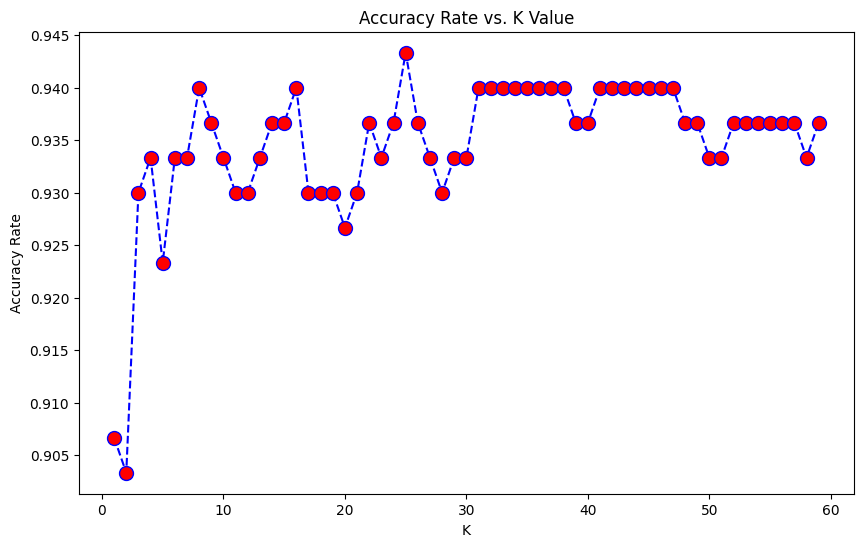

In [ ]:
# Your code starts here.
plt.figure(figsize=(10,6))
plt.plot(range(1,60),accuracy_lst,color='blue', linestyle='dashed', marker='o',markerfacecolor='red', markersize=10)
plt.title('Accuracy Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy Rate')
# Your code ends here

In [ ]:
str(max(accuracy_lst))

'0.9433333333333334'

##### **Choose the best value of n_neighbours and give a reason why and also print the accuracy**

In [ ]:
# Your code starts here.
n_acc_best = 0.94
n_neigh_best = 35
print("Best value of n_neighbours:",n_neigh_best)
print("Corresponding highest accuracy:",n_acc_best)
# Your code ends here

Best value of n_neighbours: 35
Corresponding highest accuracy: 0.94


The reason I chose K=35 because the accuracy at 35 is quite high i.e. 0.94 and the accuracy around K=35 is also quite stable. For K=26 even if accuracy is peak i.e. 0.943 its not too high from K=35 and the values around K=26 is quite unstable.

### OPTIONAL: Explainability

So you passed some data into a model, and trained it using that data. You then used some other data to test the accuracy of that model, and it now predicts values when you pass in some data. Ok. But how does it REALLY predict that value? How much is it relying on each individual feature column of data that you passed to the model? This is where the concept of explainability comes into picture, where you can understand for each data point, exactly what parameters led the model to predict the value that it has.

Info about explainable AI <br>
https://www.ibm.com/topics/explainable-ai <br>
About shap <br>
https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

In [ ]:
#Run this code as it is
from shap import KernelExplainer, force_plot, sample

In [ ]:
import shap

In [ ]:
X_test = pd.DataFrame(X_test)
X_train = pd.DataFrame(X_train)
y_train = pd.DataFrame(y_train)
y_test = pd.DataFrame(y_test)

In [ ]:
regressor.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Run this code as it is
ex = KernelExplainer(regressor.predict, sample(X_train, 10))  #only taking sample of 10 values for now
shap_values = ex.shap_values(X_test.iloc[0,:]) #explaining 1st tuple of the X_test dataframe
force_plot(ex.expected_value, shap_values, X_test.iloc[0,:], matplotlib=True)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

##### Plotting the same information in a different way

In [ ]:
explainer_ebm = shap.Explainer(regressor.predict,sample(X_train, 10))
shap_values_ebm = explainer_ebm(X_train)

PermutationExplainer explainer: 6503it [00:49, 106.40it/s]                          


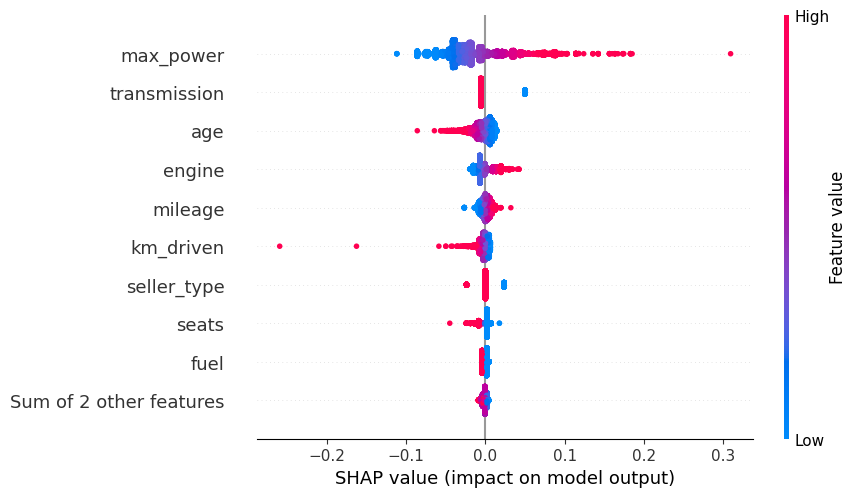

In [ ]:
shap.plots.beeswarm(shap_values_ebm)

#### Can you see how the above plot visualizes which parameters contributed significantly to the prediction, and what were the actual values which led to the prediction?

RESEARCH TASK:


A)Logistic Regression

https://ryxcommar.com/2020/06/27/why-do-so-many-practicing-data-scientists-not-understand-logistic-regression/

B) Read the above article and write you understand


What is a logit, probit?

Logistic regression comes under classification but instead of predicting the class it predicts the probability of a datapoint to belong to a class.
It usually uses sigmoid function i.e. f(x) = 1/(1 + e^(-x)) to predict the probability. This function always give value b/w 0 to 1.
Then we can decide a threshold which is generally 0.5, if probability is above 0.5 then it belongs to that particular class.

Logit(y) = ln(p/(1-p)), where p is probability

Probit is another model for binary outcome, it uses CDF i.e. cumulative distribution function of the standard normal distribution.

p = (C.D.F) * (W'.X + b)

C) Difference between logistic regression and classification

Classification is a type of supervised learning in machine learning where the goal is to assign labels (or classes) to input data based on its features. It involves building a model that can predict the class of an unseen data point.

Logistic Regression is a specific type of classification algorithm, particularly used for binary classification. It models the probability of a datapoint beloging to a class, based on one or more input features.

End of Task

©DJS Synapse 2024 - 2025